# Семинар 2. Графовые модели: что рекомендовать покупателю?
**Дополнительные главы машинного обучения · Машинное обучение в цифровом продукте**

На прошлом семинаре мы описывали покупателей давностью покупки, числом заказов и средней корзиной.
Эти признаки сохраняют активность, но теряют состав заказов. Если человек раньше покупал свечи,
а в последних заказах появилась посуда, он может остаться в том же сегменте.

Теперь нужно выбрать **десять новых для известного покупателя товаров**. Базовое решение:
популярные товары без уже купленных. Проверим, какую информацию добавляют связи между товарами
и выделение недавних покупок.

Сначала разберём матрицы, энергию сигнала и спектральный алгоритм на графах из лекции.
Затем построим рекомендации на Online Retail, сравним всю историю с последними 30 днями
и обучим LightGCN. Новое сравнение недавней истории выполняем только на validation.

Здесь реализована задача **link prediction / ranking**. Node classification, graph classification,
DeepWalk, node2vec, обычная GCN, GraphSAGE и GAT остаются обзорными темами лекции.
LightGCN показывает обучаемое распространение информации на нашей задаче.

Все ячейки выполняются последовательно через Restart Kernel → Run All.


In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 186.8 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.9/217.9 kB 607.2 kB/s eta 0:00:00a 0:00:01
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 300.5 kB/s eta 0:00:00a 0:00:01
  Using cached kiwisolver-1.5.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached filelock-3.32.7-py3-none-any.whl.metadata (2.0 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.

In [4]:
from pathlib import Path
import copy, hashlib, json, time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components, laplacian
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
from IPython.display import display
import torch
from torch import nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
ROOT = Path.cwd()
if not (ROOT / 'Данные/online_retail.csv.gz').exists():
    ROOT = ROOT / 'Занятие 02 — Графовые модели'
assert (ROOT / 'Данные/online_retail.csv.gz').exists(), 'Откройте ноутбук из папки занятия'
OUT = ROOT / 'Результаты'; OUT.mkdir(exist_ok=True)
FIG = ROOT / 'Рисунки'; FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})
pd.set_option('display.max_colwidth', 65)
START = time.time()

/var/folders/mq/zd1phr397ln068kvyvnxrdhc0000gn/T/ipykernel_95970/3713706433.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Вернёмся к покупкам
Источник: [UCI Online Retail, Daqing Chen, 2015](https://archive.ics.uci.edu/dataset/352/online+retail), CC BY 4.0.
541 909 строк - **позиции заказов**, а не число покупателей или заказов. Магазин продаёт подарки;
среди покупателей есть оптовики. Один крупный заказ может соединить множество товаров.

Посмотрим на исходную таблицу. Числовые идентификаторы не являются количественными признаками.

In [ ]:
data_path = ROOT / 'Данные/online_retail.csv.gz'
raw = pd.read_csv(data_path, encoding='ISO-8859-1', dtype={'InvoiceNo': str, 'StockCode': str, 'CustomerID': str})
raw['InvoiceDate'] = pd.to_datetime(raw['InvoiceDate'], format='%m/%d/%Y %H:%M')
print(f'Строк: {len(raw):,}; SHA256: {hashlib.sha256(data_path.read_bytes()).hexdigest()}')
display(raw.head())

Строк: 541,909; SHA256: d382bb7eebaf784547ed46183191a01a2360ef26dfb92a7310d8963406ea878e


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Очистка и границы задачи
Оставляем Великобританию, положительные продажи с известным покупателем и обычным товарным кодом.
Удаляем точные дубликаты и отмены. Это история положительных покупок; последующие возвраты
не вычитаем и чистую выручку не оцениваем. Названия используем только для интерпретации.

In [ ]:
masks = {
    'Известен покупатель': raw.CustomerID.notna(),
    'Великобритания': raw.Country.eq('United Kingdom'),
    'Положительные количество и цена': raw.Quantity.gt(0) & raw.UnitPrice.gt(0),
    'Не отмена': ~raw.InvoiceNo.str.upper().str.startswith('C'),
    'Товарный код': raw.StockCode.str.fullmatch(r'\d{5}[A-Za-z]*', na=False),
}
keep = pd.Series(True, index=raw.index)
audit = []
for name, mask in masks.items():
    keep &= mask
    audit.append({'Шаг': name, 'Осталось строк': int(keep.sum())})
sales = raw.loc[keep].drop_duplicates().copy()
audit.append({'Шаг': 'Без точных дубликатов', 'Осталось строк': len(sales)})
display(pd.DataFrame(audit))

,Шаг,Осталось строк
0,Известен покупатель,406829
1,Великобритания,361878
2,Положительные количество и цена,354321
3,Не отмена,354321
4,Товарный код,353985
5,Без точных дубликатов,348872


## 2. Сначала протокол оценки, потом граф
Представим, что рекомендации сформированы **1 сентября 2011 года**.

- Train: покупки до 1 сентября. Только они задают каталог, графы, популярность и embeddings.
- Validation: сентябрь-октябрь. Выбираем шаг обучения по качеству моделей.
- Test: с 1 ноября до конца наблюдения. Ранее использовался для итогового сравнения шести базовых моделей.

Для простоты это **фиксированные рекомендации по августовской истории**: модель не обновляется в ноябре.
Сентябрьские и октябрьские покупки не добавляем в граф. Повторные покупки товаров из train не являются целью:
мы решаем задачу открытия новых для пользователя товаров. Для пополнения привычной корзины нужен другой протокол.

Каталог ограничиваем товарами минимум из 10 обучающих заказов, а пользователей - минимум 3 товарами этого каталога.
Пороги заданы до оценки. Новые пользователи и новые товары требуют отдельного cold-start решения.

Добавленный после лекции эксперимент с последними 30 днями использует только train и validation.
Test уже просмотрен: он не является новым независимым подтверждением для этого изменения.
Граф товаров фиксируем на 1 сентября; меняем вес истории пользователя, а не обновляем граф в ноябре.


In [ ]:
CUT_VAL = pd.Timestamp('2011-09-01')
CUT_TEST = pd.Timestamp('2011-11-01')
train_all = sales[sales.InvoiceDate < CUT_VAL].copy()
val_raw = sales[(sales.InvoiceDate >= CUT_VAL) & (sales.InvoiceDate < CUT_TEST)].copy()
test_raw = sales[sales.InvoiceDate >= CUT_TEST].copy()
item_support = train_all.groupby('StockCode').InvoiceNo.nunique()
items = np.array(sorted(item_support[item_support >= 10].index))
train = train_all[train_all.StockCode.isin(items)].copy()
user_support = train.groupby('CustomerID').StockCode.nunique()
users = np.array(sorted(user_support[user_support >= 3].index))
train = train[train.CustomerID.isin(users)].copy()
# После фильтра пользователей удаляем потенциально пустые столбцы.
items = np.array(sorted(train.StockCode.unique()))
ui = {u: i for i, u in enumerate(users)}; ii = {x: i for i, x in enumerate(items)}
nu, ni = len(users), len(items)
pairs = train[['CustomerID', 'StockCode']].drop_duplicates()
R = sp.csr_matrix((np.ones(len(pairs), dtype=np.float32),
                   (pairs.CustomerID.map(ui), pairs.StockCode.map(ii))), shape=(nu, ni))
seen = [set(R[u].indices) for u in range(nu)]
names = train.groupby('StockCode').Description.agg(lambda s: s.dropna().mode().iloc[0] if s.notna().any() else '?')
pop = np.asarray(R.sum(axis=0)).ravel()
print(f'Граф: {nu:,} покупателей, {ni:,} товаров, {R.nnz:,} уникальных покупок')
assert train.InvoiceDate.max() < CUT_VAL <= val_raw.InvoiceDate.min()
assert val_raw.InvoiceDate.max() < CUT_TEST <= test_raw.InvoiceDate.min()
assert np.all(R.data == 1) and ni >= 10

Граф: 2,850 покупателей, 2,351 товаров, 139,672 уникальных покупок


In [ ]:
def make_targets(frame):
    targets = {}
    for customer, group in frame.groupby('CustomerID'):
        if customer not in ui:
            continue
        u = ui[customer]
        new_items = {ii[x] for x in group.StockCode if x in ii} - seen[u]
        if new_items:
            targets[u] = new_items
    return targets

val_targets = make_targets(val_raw)
# Пока считаем только доступность теста, не качество моделей.
def coverage_report(frame, name):
    known = frame.CustomerID.isin(users) & frame.StockCode.isin(items)
    eligible = make_targets(frame)
    return {'Период': name, 'Всего покупателей': frame.CustomerID.nunique(),
            'Оцениваемых покупателей': len(eligible),
            'Доля строк с известными пользователем и товаром': known.mean()}
display(pd.DataFrame([coverage_report(val_raw, 'Validation'), coverage_report(test_raw, 'Test')]))
assert val_targets

,Период,Всего покупателей,Оцениваемых покупателей,Доля строк с известными пользователем и товаром
0,Validation,1925,1233,0.646367
1,Test,1721,1135,0.619236


### Что измеряем
Для каждого подходящего покупателя ранжируем **весь обучающий каталог**, исключая товары из его train-истории.
Тест не ограничиваем случайными отрицательными примерами.

- **Recall@10:** доля будущих новых товаров пользователя, найденных в десятке.
- **NDCG@10:** учитывает позиции попаданий; раннее попадание ценнее.
- **HitRate@10:** доля пользователей хотя бы с одним попаданием.
- **CatalogCoverage@10:** доля каталога, попавшая в рекомендации хотя бы одному оцениваемому пользователю.

Усредняем по пользователям с хотя бы одной доступной новой покупкой. Поэтому это качество на указанной когорте,
а не на всех посетителях магазина. Большой охват каталога сам по себе не означает полезные рекомендации.

In [ ]:
K = 10
pop_scores = np.broadcast_to(pop, (nu, ni)).copy()

def rank_topk(scores, user_ids):
    s = np.asarray(scores[user_ids], dtype=np.float32).copy()
    for row, u in enumerate(user_ids):
        s[row, list(seen[u])] = -np.inf
    assert np.all(np.isfinite(s).sum(axis=1) >= K)
    # Stable sort: при равенстве score порядок определяется кодом товара.
    return np.argsort(-s, axis=1, kind='stable')[:, :K]

def evaluate(scores, targets):
    ids = np.array(sorted(targets))
    top = rank_topk(scores, ids)
    rows = []
    discount = 1 / np.log2(np.arange(2, K + 2))
    for u, rec in zip(ids, top):
        rel = np.array([i in targets[u] for i in rec])
        rows.append((rel.sum() / len(targets[u]),
                     (rel * discount).sum() / discount[:min(K, len(targets[u]))].sum(),
                     float(rel.any())))
    result = dict(zip(['Recall@10', 'NDCG@10', 'HitRate@10'], np.mean(rows, axis=0)))
    result['CatalogCoverage@10'] = len(np.unique(top)) / ni
    return result

# Проверяем метрику на известном ответе: единственный правильный товар на первом месте.
u0 = min(val_targets)
i0 = min(val_targets[u0])
probe = np.zeros((nu, ni), dtype=np.float32); probe[u0, i0] = 100
assert evaluate(probe, {u0: {i0}})['NDCG@10'] == 1
assert not (set(rank_topk(pop_scores, [u0])[0]) & seen[u0])
display(pd.Series(evaluate(pop_scores, val_targets), name='Популярность: validation'))

Recall@10             0.023866
NDCG@10               0.045592
HitRate@10            0.306569
CatalogCoverage@10    0.023394
Name: Популярность: validation, dtype: float64

## 3. Граф товаров: какие товары встречаются в одном заказе?
Матрица $B$: строки - заказы, столбцы - товары, элемент равен 1 при покупке.
$B^\top B$ считает совместные заказы. Нормируем на частоты товаров, получая косинусное сходство
столбцов $B$. Убираем диагональ и оставляем до 20 сильнейших связей каждой вершины;
симметризуем максимумом. После симметризации степень может превышать 20.

Это **граф совместной покупки**, а не гарантия взаимозаменяемости: чайник и чашка могут дополнять друг друга.
Большие оптовые корзины и популярность влияют на рёбра даже после нормировки.

Товаров: 2351; рёбер: 31075; компонент: 1


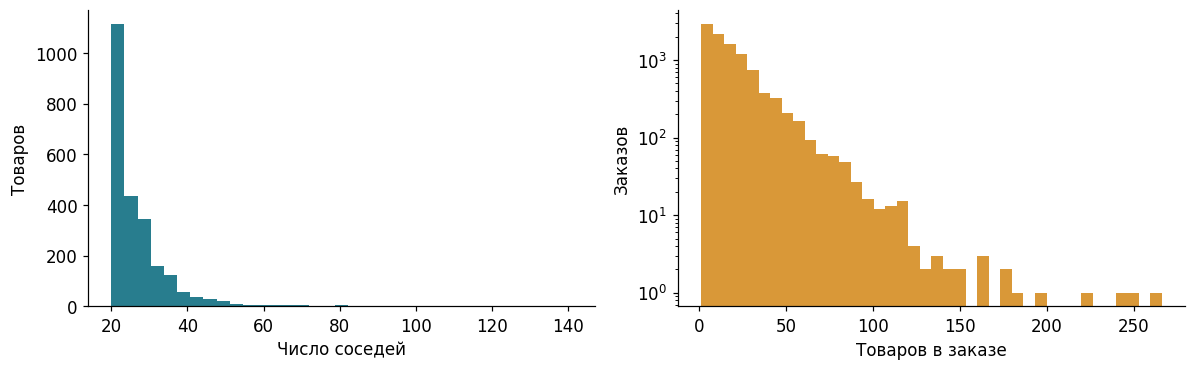

In [ ]:
basket_pairs = train[['InvoiceNo', 'StockCode']].drop_duplicates()
basket_ids = {x: i for i, x in enumerate(sorted(basket_pairs.InvoiceNo.unique()))}
B = sp.csr_matrix((np.ones(len(basket_pairs), dtype=np.float32),
                  (basket_pairs.InvoiceNo.map(basket_ids), basket_pairs.StockCode.map(ii))),
                 shape=(len(basket_ids), ni))
Bn = normalize(B, axis=0)
S = (Bn.T @ Bn).tocsr(); S.setdiag(0); S.eliminate_zeros()

def top_neighbors(matrix, k=20):
    rr, cc, vv = [], [], []
    for i in range(matrix.shape[0]):
        row = matrix.getrow(i)
        pos = np.argsort(-row.data, kind='stable')[:k]
        rr.extend([i] * len(pos)); cc.extend(row.indices[pos]); vv.extend(row.data[pos])
    out = sp.csr_matrix((vv, (rr, cc)), shape=matrix.shape)
    return out.maximum(out.T)

W = top_neighbors(S)
ncomp, component = connected_components(W, directed=False)
print(f'Товаров: {ni}; рёбер: {W.nnz // 2}; компонент: {ncomp}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(np.diff(W.indptr), bins=35, color='#287d8e'); ax[0].set(xlabel='Число соседей', ylabel='Товаров')
ax[1].hist(B.sum(axis=1).A.ravel(), bins=40, color='#d99838'); ax[1].set(xlabel='Товаров в заказе', ylabel='Заказов', yscale='log')
plt.tight_layout(); plt.savefig(FIG / '01_graph_structure.png'); plt.show()

## 4. Спектральная кластеризация: группы без готовых категорий
Для ненормированного лапласиана $L=D-W$:
$$f^\top Lf=\frac12\sum_{i,j}w_{ij}(f_i-f_j)^2.$$
Малое значение означает, что на сильных связях значения сигнала похожи.
В эксперименте используем $L_{sym}=I-D^{-1/2}WD^{-1/2}$.
Берём собственные векторы с наименьшими собственными значениями, нормируем строки и запускаем K-means.

Работаем с крупнейшей компонентой: остальные товары **не исчезают из оценки рекомендаций**,
для них ниже предусмотрено базовое решение. Число групп 8 задано заранее. Оно не означает, что в каталоге объективно существует ровно восемь категорий.

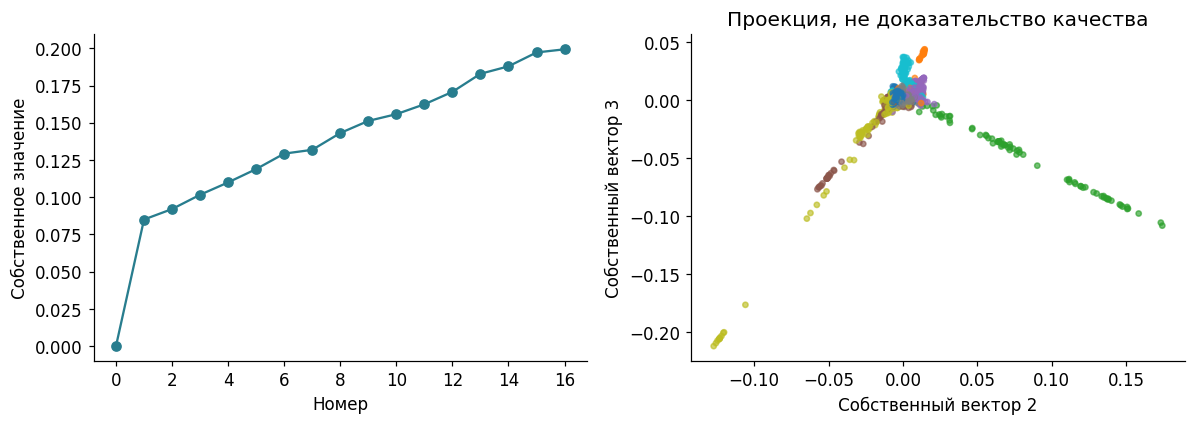

Крупнейшая компонента: 2351 / 2351 товаров


In [ ]:
largest = np.argmax(np.bincount(component))
active = np.flatnonzero(component == largest)
Wc = W[active][:, active].astype(np.float64)
L_sym = laplacian(Wc, normed=True)
N_CLUSTERS = 8
vals, vecs = eigsh(L_sym, k=17, which='SM', v0=np.random.default_rng(SEED).normal(size=len(active)))
order = np.argsort(vals); vals, vecs = vals[order], vecs[:, order]
assert (W - W.T).nnz == 0
assert vals.min() > -1e-6
Zcluster = normalize(vecs[:, :N_CLUSTERS])
labels = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=SEED).fit_predict(Zcluster)
item_cluster = np.full(ni, -1); item_cluster[active] = labels
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(np.arange(len(vals)), vals, 'o-', color='#287d8e'); ax[0].set(xlabel='Номер', ylabel='Собственное значение')
ax[1].scatter(vecs[:, 1], vecs[:, 2], c=labels, cmap='tab10', s=12, alpha=.65)
ax[1].set(xlabel='Собственный вектор 2', ylabel='Собственный вектор 3', title='Проекция, не доказательство качества')
plt.tight_layout(); plt.savefig(FIG / '02_spectral.png'); plt.show()
print(f'Крупнейшая компонента: {len(active)} / {ni} товаров')

In [ ]:
cluster_rows = []
for group in range(N_CLUSTERS):
    ids = np.flatnonzero(item_cluster == group)
    top = ids[np.argsort(-pop[ids])[:6]]
    cluster_rows.append({'Группа': group, 'Товаров': len(ids),
                         'Популярные примеры': '; '.join(names[items[i]] for i in top)})
display(pd.DataFrame(cluster_rows))

,Группа,Товаров,Популярные примеры
0,0,834,SCOTTIE DOG HOT WATER BOTTLE; RETROSPOT HEART HOT WATER BOTTL...
1,1,72,SET/20 RED RETROSPOT PAPER NAPKINS ; PAPER BUNTING RETROSPOT;...
2,2,76,SWALLOWS GREETING CARD; CARD BILLBOARD FONT; SPACEBOY BIRTHDA...
3,3,226,BAKING SET 9 PIECE RETROSPOT ; FELTCRAFT 6 FLOWER FRIENDS; RE...
4,4,222,REGENCY CAKESTAND 3 TIER; ROSES REGENCY TEACUP AND SAUCER ; G...
5,5,484,PACK OF 72 RETROSPOT CAKE CASES; JAM MAKING SET WITH JARS; JA...
6,6,275,WHITE HANGING HEART T-LIGHT HOLDER; ASSORTED COLOUR BIRD ORNA...
7,7,162,PARTY BUNTING; JUMBO BAG RED RETROSPOT; SPOTTY BUNTING; LUNCH...


Группы могут отражать стиль, частоту покупки или сезонность. Названия и состав товаров помогают
интерпретировать результат. Мы не располагаем эталонными категориями и не будем
создавать их из этих же кластеров ради «точности классификации».

Превратим группы в простой рекомендатель: предпочтение пользователя к группе - доля его истории в ней;
внутри группы ранжируем по популярности. Для товаров вне крупнейшей компоненты оставляем небольшой
популярностный score. Это эвристика, качество которой ещё нужно проверить.

In [ ]:
membership = np.zeros((ni, N_CLUSTERS), dtype=np.float32)
membership[active, labels] = 1
preferences = normalize(np.asarray(R @ membership), norm='l1')
cluster_scores = (preferences @ membership.T) * (pop / pop.max())[None, :]
cluster_scores += 1e-6 * pop[None, :] / pop.max()

## 5. От групп к распространению и непрерывным embeddings
**Распространение интереса:** $s_u=R_uP$, где $P=D^{-1}W$ - вероятности перехода по товарному графу.
Товары из истории передают часть веса соседям. Это распространение сигналов, не label propagation классов.

**Спектральные embeddings:** берём 16 нетривиальных собственных векторов. Профиль пользователя - среднее
представлений его покупок; score товара - косинусное сходство с этим профилем.
Вне компоненты нет такого представления; при нулевом профиле используем популярность.

In [ ]:
P = normalize(W, norm='l1', axis=1)
diffusion_scores = (R @ P).toarray()
E = np.zeros((ni, 16), dtype=np.float32)
E[active] = normalize(vecs[:, 1:17])
profiles = normalize(np.asarray(R @ E))
spectral_scores = profiles @ E.T
missing_profile = np.linalg.norm(profiles, axis=1) == 0
spectral_scores[missing_profile] = pop / pop.max()
# Для остальных пользователей товары без embeddings ставим после товаров с представлениями.
spectral_scores[np.ix_(~missing_profile, item_cluster == -1)] = -2 + (pop[item_cluster == -1] / pop.max())[None, :] * .01
scores_by_model = {'Популярность': pop_scores, 'Спектральные группы': cluster_scores,
                   'Распространение': diffusion_scores, 'Спектральные embeddings': spectral_scores}
validation = pd.DataFrame({name: evaluate(scores, val_targets) for name, scores in scores_by_model.items()}).T
display(validation.round(4))

,Recall@10,NDCG@10,HitRate@10,CatalogCoverage@10
Популярность,0.0239,0.0456,0.3066,0.0234
Спектральные группы,0.0304,0.0574,0.3414,0.0757
Распространение,0.0560,0.0980,0.4485,0.6674
Спектральные embeddings,0.0219,0.0332,0.2028,0.7252


## 5.1. Если последние покупки отличаются от старой истории
В исходном $R$ все когда-либо купленные до 1 сентября товары имеют вес 1.
В новом варианте единицы получают только товары из **последних 30 дней до 1 сентября**:
$$s_u^{\mathrm{recent}}=r_u^{\mathrm{recent}}P.$$

Граф и матрица переходов $P$ одинаковые у двух методов. Меняется только профиль покупателя.
Окно 30 дней фиксируем до просмотра нового сравнения. Не подбираем его по test.
Если недавних покупок нет, используем всю train-историю. Уже купленные товары исключаем
по всей истории в обоих вариантах, поэтому кандидаты и целевые покупки совпадают.

Рекомендации формируются на 1 сентября. Это проверка роли свежести доступной истории,
а не эксперимент с ежедневным обновлением графа или событиями после этой даты.


In [ ]:
RECENT_DAYS = 30
RECENT_START = CUT_VAL - pd.Timedelta(days=RECENT_DAYS)

def interaction_matrix(frame):
    unique = frame[['CustomerID', 'StockCode']].drop_duplicates()
    return sp.csr_matrix((np.ones(len(unique), dtype=np.float32),
                          (unique.CustomerID.map(ui), unique.StockCode.map(ii))), shape=R.shape)

recent_train = train[train.InvoiceDate >= RECENT_START].copy()
older_train = train[train.InvoiceDate < RECENT_START].copy()
R_recent = interaction_matrix(recent_train)
R_older = interaction_matrix(older_train)
has_recent = np.diff(R_recent.indptr) > 0
recent_scores = (R_recent @ P).toarray()
recent_scores[~has_recent] = diffusion_scores[~has_recent]
assert recent_train.InvoiceDate.min() >= RECENT_START
assert recent_train.InvoiceDate.max() < CUT_VAL
assert (R_recent - R_recent.multiply(R)).nnz == 0
assert np.allclose(recent_scores[~has_recent], diffusion_scores[~has_recent])
print('Окно:', RECENT_START.date(), 'до', CUT_VAL.date(), '(правая граница не включается)')
print('Покупателей с недавними покупками:', int(has_recent.sum()), 'из', nu)

recent_validation_targets = {u: target for u, target in val_targets.items() if has_recent[u]}
recency_rows = []
for cohort, targets in [('Все оцениваемые покупатели', val_targets),
                        ('Есть покупки за 30 дней', recent_validation_targets)]:
    assert targets
    for method, score in [('Вся история', diffusion_scores), ('Последние 30 дней + fallback', recent_scores)]:
        recency_rows.append({'Когорта': cohort, 'История': method, 'Покупателей': len(targets),
                             **evaluate(score, targets)})
recency_metrics = pd.DataFrame(recency_rows)
display(recency_metrics.round(4))
recency_metrics.to_csv(OUT / 'recency_validation_metrics.csv', index=False)
# Отдельный словарь: этот вариант не попадёт в исходную тестовую таблицу.
recency_scores_by_model = {'Вся история': diffusion_scores, 'Последние 30 дней + fallback': recent_scores}


Окно: 2011-08-02 до 2011-09-01 (правая граница не включается)
Покупателей с недавними покупками: 795 из 2850


,Когорта,История,Покупателей,Recall@10,NDCG@10,HitRate@10,CatalogCoverage@10
0,Все оцениваемые покупатели,Вся история,1233,0.0560,0.0980,0.4485,0.6674
1,Все оцениваемые покупатели,Последние 30 дней + fallback,1233,0.0561,0.0976,0.4371,0.7176
2,Есть покупки за 30 дней,Вся история,478,0.0580,0.0940,0.4519,0.4632
3,Есть покупки за 30 дней,Последние 30 дней + fallback,478,0.0582,0.0929,0.4226,0.5304


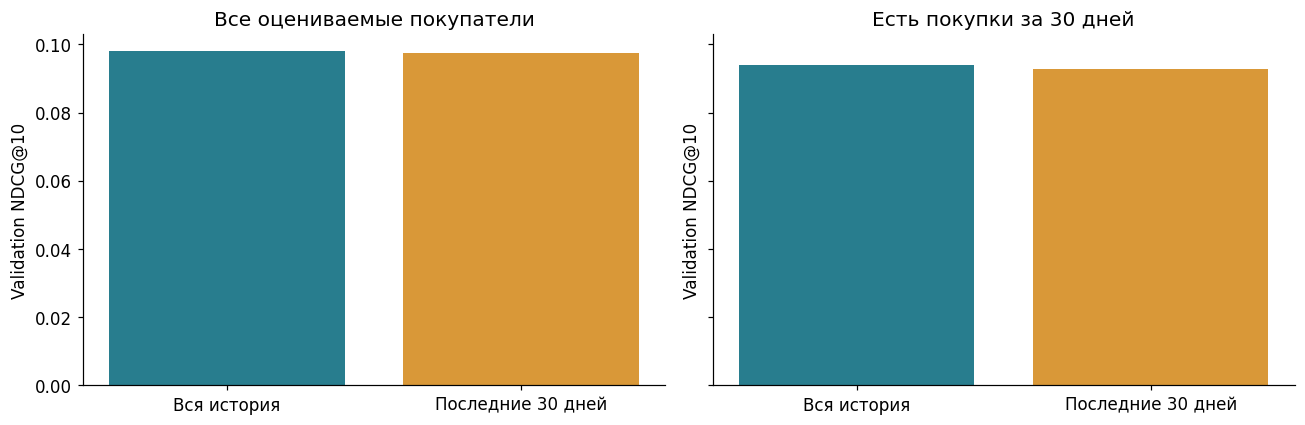

Все оцениваемые покупатели: изменение NDCG@10 = -0.0004
Есть покупки за 30 дней: изменение NDCG@10 = -0.0011
Свежее окно может потерять полезную старую историю. Смотрим на результат, а не предполагаем выигрыш.
На всей validation-когорте выигрыша по NDCG@10 нет. Изменение выдачи не гарантирует улучшения качества.
Статистическую значимость разницы здесь не оценивали.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, cohort in zip(axes, recency_metrics['Когорта'].unique()):
    table = recency_metrics[recency_metrics['Когорта'] == cohort].set_index('История')
    ax.bar(['Вся история', 'Последние 30 дней'], table['NDCG@10'], color=['#287d8e', '#d99838'])
    ax.set(title=cohort, ylabel='Validation NDCG@10')
plt.tight_layout(); plt.savefig(FIG / '05_recency_validation.png'); plt.show()
for cohort in recency_metrics['Когорта'].unique():
    part = recency_metrics[recency_metrics['Когорта'] == cohort].set_index('История')
    delta = part.loc['Последние 30 дней + fallback', 'NDCG@10'] - part.loc['Вся история', 'NDCG@10']
    print(f'{cohort}: изменение NDCG@10 = {delta:+.4f}')
print('Свежее окно может потерять полезную старую историю. Смотрим на результат, а не предполагаем выигрыш.')

all_cohort = recency_metrics[recency_metrics['Когорта'].eq('Все оцениваемые покупатели')].set_index('История')
all_ndcg_delta = all_cohort.loc['Последние 30 дней + fallback', 'NDCG@10'] - all_cohort.loc['Вся история', 'NDCG@10']
if all_ndcg_delta > 0:
    print('На всей validation-когорте NDCG@10 вырос; это пока не независимая итоговая оценка.')
else:
    print('На всей validation-когорте выигрыша по NDCG@10 нет. Изменение выдачи не гарантирует улучшения качества.')
print('Статистическую значимость разницы здесь не оценивали.')


## 5.2. Покупатель с изменившимся составом заказов
Для интерпретации сравним распределение старых и недавних покупок по спектральным группам.
Выбираем покупателя **только по train**: минимум 5 разных старых и 3 недавних товара,
ведущая группа в этих периодах различается. Среди подходящих берём покупателя с медианным
различием распределений; номера групп не являются категориями из готовой разметки.

Если при других данных таких покупателей нет, код выбирает покупателя из тех, у кого достаточно
истории, и сообщает об этом. Результаты validation и test в выборе примера не участвуют.
Изменение состава покупок может быть связано с подарком или сезонностью и не доказывает устойчивую смену вкуса.


In [ ]:
older_preferences = normalize(np.asarray(R_older @ membership), norm='l1')
recent_preferences = normalize(np.asarray(R_recent @ membership), norm='l1')
history_shift = .5 * np.abs(older_preferences - recent_preferences).sum(axis=1)
enough_history = (np.diff(R_older.indptr) >= 5) & (np.diff(R_recent.indptr) >= 3)
enough_history &= (older_preferences.sum(axis=1) > 0) & (recent_preferences.sum(axis=1) > 0)
changed_group = older_preferences.argmax(axis=1) != recent_preferences.argmax(axis=1)
case_pool = np.flatnonzero(enough_history & changed_group)
if len(case_pool) == 0:
    case_pool = np.flatnonzero(enough_history)
    print('Смена ведущей группы не найдена; показываем сравнение при достаточной истории.')
if len(case_pool) == 0:
    raise ValueError('Нет покупателей с достаточной историей для этого разбора.')
case_order = sorted(case_pool, key=lambda u: (history_shift[u], u))
recency_u = case_order[len(case_order) // 2]
print('Покупатель:', users[recency_u], '| различие профилей:', round(float(history_shift[recency_u]), 3))
print('Выбран без использования будущих покупок и попаданий рекомендаций.')
profile_comparison = pd.DataFrame({'Группа': np.arange(N_CLUSTERS),
                                   'Доля старой истории': older_preferences[recency_u],
                                   'Доля последних 30 дней': recent_preferences[recency_u]})
display(profile_comparison.round(3))
profile_comparison.to_csv(OUT / 'recency_example_profile.csv', index=False)
history_parts = []
for period_name, period_frame in [('До окна 30 дней', older_train), ('Последние 30 дней', recent_train)]:
    part = (period_frame[period_frame.CustomerID.eq(users[recency_u])]
            .sort_values(['InvoiceDate', 'InvoiceNo', 'StockCode'])
            .drop_duplicates('StockCode', keep='last').tail(12)
            [['InvoiceDate', 'StockCode', 'Description']].copy())
    part.insert(0, 'Период', period_name)
    history_parts.append(part)
    print(period_name + ': последние разные товары в этом периоде')
    display(part.rename(columns={'InvoiceDate': 'Дата', 'StockCode': 'Код', 'Description': 'Товар'}))
pd.concat(history_parts).to_csv(OUT / 'recency_example_purchases.csv', index=False)
all_rec = rank_topk(diffusion_scores, [recency_u])[0]
recent_rec = rank_topk(recent_scores, [recency_u])[0]
assert not (set(all_rec) | set(recent_rec)) & seen[recency_u]
recency_example = pd.DataFrame({'Место': np.arange(1, K + 1),
    'Код: вся история': items[all_rec], 'Вся история': [names[items[i]] for i in all_rec],
    'Код: последние 30 дней': items[recent_rec], 'Последние 30 дней': [names[items[i]] for i in recent_rec]})
display(recency_example)
recency_example.to_csv(OUT / 'recency_recommendation_example.csv', index=False)
print('Общих товаров в двух десятках:', len(set(all_rec) & set(recent_rec)))
print('Сравнение показывает реакцию выдачи на профиль; качество оценивается по всей validation-когорте.')


Покупатель: 17428 | различие профилей: 0.408
Выбран без использования будущих покупок и попаданий рекомендаций.


,Группа,Доля старой истории,Доля последних 30 дней
0,0,0.183,0.053
1,1,0.016,0.000
2,2,0.031,0.000
3,3,0.058,0.000
4,4,0.194,0.526
5,5,0.173,0.000
6,6,0.063,0.105
7,7,0.283,0.316


До окна 30 дней: последние разные товары в этом периоде


,Период,Дата,Код,Товар
253075,До окна 30 дней,2011-07-06 16:03:00,20713,JUMBO BAG OWLS
253068,До окна 30 дней,2011-07-06 16:03:00,21400,RED PUDDING SPOON
253069,До окна 30 дней,2011-07-06 16:03:00,21401,BLUE PUDDING SPOON
253071,До окна 30 дней,2011-07-06 16:03:00,21731,RED TOADSTOOL LED NIGHT LIGHT
253072,До окна 30 дней,2011-07-06 16:03:00,21916,SET 12 RETRO WHITE CHALK STICKS
253063,До окна 30 дней,2011-07-06 16:03:00,23028,DRAWER KNOB CRACKLE GLAZE BLUE
253064,До окна 30 дней,2011-07-06 16:03:00,23029,DRAWER KNOB CRACKLE GLAZE GREEN
253065,До окна 30 дней,2011-07-06 16:03:00,23031,DRAWER KNOB CRACKLE GLAZE PINK
253067,До окна 30 дней,2011-07-06 16:03:00,23032,DRAWER KNOB CRACKLE GLAZE IVORY
253066,До окна 30 дней,2011-07-06 16:03:00,23034,DRAWER KNOB CERAMIC BLACK


Последние 30 дней: последние разные товары в этом периоде


,Период,Дата,Код,Товар
291343,Последние 30 дней,2011-08-04 19:22:00,23110,PARISIENNE KEY CABINET
291345,Последние 30 дней,2011-08-04 19:22:00,23111,PARISIENNE SEWING BOX
291344,Последние 30 дней,2011-08-04 19:22:00,23112,PARISIENNE CURIO CABINET
291346,Последние 30 дней,2011-08-04 19:22:00,23118,PARISIENNE JEWELLERY DRAWER
291349,Последние 30 дней,2011-08-04 19:22:00,23204,CHARLOTTE BAG APPLES DESIGN
291352,Последние 30 дней,2011-08-04 19:22:00,23205,CHARLOTTE BAG VINTAGE ALPHABET
291355,Последние 30 дней,2011-08-04 19:22:00,23275,SET OF 3 HANGING OWLS OLLIE BEAK
291356,Последние 30 дней,2011-08-04 19:22:00,84879,ASSORTED COLOUR BIRD ORNAMENT
307280,Последние 30 дней,2011-08-21 12:37:00,22697,GREEN REGENCY TEACUP AND SAUCER
307281,Последние 30 дней,2011-08-21 12:37:00,22699,ROSES REGENCY TEACUP AND SAUCER


,Место,Код: вся история,Вся история,Код: последние 30 дней,Последние 30 дней
0,1,22383,LUNCH BAG SUKI DESIGN,22356,CHARLOTTE BAG PINK POLKADOT
1,2,20727,LUNCH BAG BLACK SKULL.,23108,SET OF 10 LED DOLLY LIGHTS
2,3,22386,JUMBO BAG PINK POLKADOT,22383,LUNCH BAG SUKI DESIGN
3,4,22384,LUNCH BAG PINK POLKADOT,20727,LUNCH BAG BLACK SKULL.
4,5,23199,JUMBO BAG APPLES,23298,SPOTTY BUNTING
5,6,23050,RECYCLED ACAPULCO MAT GREEN,22384,LUNCH BAG PINK POLKADOT
6,7,82482,WOODEN PICTURE FRAME WHITE FINISH,23094,LE GRAND TRAY CHIC SET
7,8,85123A,WHITE HANGING HEART T-LIGHT HOLDER,23161,REGENCY CAKE FORK
8,9,22720,SET OF 3 CAKE TINS PANTRY DESIGN,23199,JUMBO BAG APPLES
9,10,22356,CHARLOTTE BAG PINK POLKADOT,82482,WOODEN PICTURE FRAME WHITE FINISH


Общих товаров в двух десятках: 6
Сравнение показывает реакцию выдачи на профиль; качество оценивается по всей validation-когорте.


## 6. Обучаемая графовая модель: LightGCN
Теперь строим **двудольный граф**: покупатели и товары - разные типы вершин, ребро означает покупку в train.

LightGCN - специализированная графовая модель рекомендаций. В отличие от обычной GCN она не использует
нелинейности и матрицы преобразования в каждом слое; обучаются начальные embeddings вершин.
$$E^{(l+1)}=D^{-1/2}AD^{-1/2}E^{(l)},\qquad
\bar E=\frac1{L+1}\sum_{l=0}^{L}E^{(l)}.$$
Score пары - скалярное произведение итоговых embeddings пользователя и товара.
Обучаем BPR: наблюдавшийся товар должен получать больший score, чем случайный ненаблюдавшийся.
Ненаблюдавшийся товар не обязательно не нравится пользователю - это предположение implicit feedback.

**Контрольный эксперимент:** та же модель при 0 слоях - матричная факторизация с BPR.
Сравнение 0 и 2 слоёв помогает оценить вклад агрегации, а не только наличия обучаемых embeddings.
Node2vec можно добавить отдельно; здесь уже есть спектральные embeddings и обучаемые графовые представления.

In [ ]:
A = sp.bmat([[None, R], [R.T, None]], format='csr', dtype=np.float32)
node_degrees = np.asarray(A.sum(axis=1)).ravel()
Dinv = sp.diags(1 / np.sqrt(np.maximum(node_degrees, 1)))
An = (Dinv @ A @ Dinv).tocoo()
At = torch.sparse_coo_tensor(torch.tensor(np.vstack([An.row, An.col]), dtype=torch.long),
                            torch.tensor(An.data, dtype=torch.float32), An.shape).coalesce()

class LightGCN(nn.Module):
    def __init__(self, layers, dim=32):
        super().__init__()
        self.layers = layers
        self.embedding = nn.Embedding(nu + ni, dim)
        nn.init.normal_(self.embedding.weight, std=.1)
    def forward(self):
        e = self.embedding.weight
        states = [e]
        for _ in range(self.layers):
            e = torch.sparse.mm(At, e)
            states.append(e)
        return torch.stack(states).mean(0)
    @torch.no_grad()
    def scores(self):
        e = self()
        return (e[:nu] @ e[nu:].T).numpy()

### Обучение и выбор шага по validation
Используем одни и те же seed, размерность и BPR-тройки для обеих моделей.
Один шаг обучения состоит из случайного батча из 8192 троек «пользователь, купленный товар,
ненаблюдавшийся товар» и одного обновления параметров. Это не полный проход по обучающим данным.
Бюджет каждой модели составляет 100 шагов; validation NDCG@10 проверяем каждые 10 шагов
и в конце обучения. Сохраняем параметры с лучшим значением на validation.

Отрицательные товары исключаем по **train**, не подглядывая в будущие покупки.
Test не участвует ни в градиентах, ни в выборе шага.
Если лучший результат достигнут на последнем шаге, бюджет мог ограничить качество.
Код выводит предупреждение: такой результат не подтверждает сходимость модели.

Слоёв 0: выбран шаг 100 из 100, validation NDCG@10=0.0577
Внимание: лучший validation NDCG@10 достигнут на последнем шаге. Бюджет мог ограничить качество; сходимость не подтверждена.


Слоёв 2: выбран шаг 100 из 100, validation NDCG@10=0.0680
Внимание: лучший validation NDCG@10 достигнут на последнем шаге. Бюджет мог ограничить качество; сходимость не подтверждена.


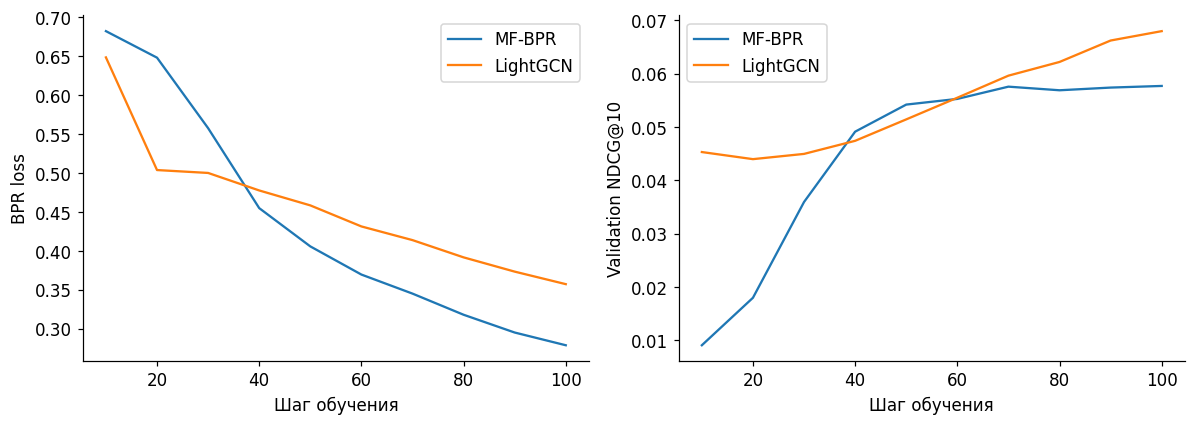

In [ ]:
pos_u, pos_i = R.nonzero()
TRAIN_STEPS = 100
BATCH = 8192

def fit_model(layers):
    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)
    model = LightGCN(layers)
    opt = torch.optim.Adam(model.parameters(), lr=.02)
    best_metric = -np.inf; best_state = None; history = []
    for step in range(1, TRAIN_STEPS + 1):
        pick = rng.integers(len(pos_u), size=BATCH)
        u = pos_u[pick]; p = pos_i[pick]
        neg = rng.integers(ni, size=BATCH)
        bad = np.array([j in seen[a] for a, j in zip(u, neg)])
        while bad.any():
            neg[bad] = rng.integers(ni, size=bad.sum())
            bad = np.array([j in seen[a] for a, j in zip(u, neg)])
        ut, pt, nt = [torch.tensor(x, dtype=torch.long) for x in (u, p + nu, neg + nu)]
        e = model()
        margin = (e[ut] * (e[pt] - e[nt])).sum(1)
        reg = sum(model.embedding(x).square().sum(1).mean() for x in (ut, pt, nt))
        loss = torch.nn.functional.softplus(-margin).mean() + 1e-4 * reg
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 10 == 0 or step == TRAIN_STEPS:
            metric = evaluate(model.scores(), val_targets)['NDCG@10']
            history.append({'Шаг обучения': step, 'BPR loss': loss.item(), 'Validation NDCG@10': metric})
            if metric > best_metric:
                best_metric = metric; best_state = copy.deepcopy(model.state_dict()); best_step = step
    model.load_state_dict(best_state)
    print(f'Слоёв {layers}: выбран шаг {best_step} из {TRAIN_STEPS}, validation NDCG@10={best_metric:.4f}')
    if best_step == TRAIN_STEPS:
        print('Внимание: лучший validation NDCG@10 достигнут на последнем шаге. '
              'Бюджет мог ограничить качество; сходимость не подтверждена.')
    return model, pd.DataFrame(history), best_step

mf, hist_mf, step_mf = fit_model(0)
gcn, hist_gcn, step_gcn = fit_model(2)
scores_by_model['MF-BPR (0 слоёв)'] = mf.scores()
scores_by_model['LightGCN (2 слоя)'] = gcn.scores()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for h, label in [(hist_mf, 'MF-BPR'), (hist_gcn, 'LightGCN')]:
    ax[0].plot(h['Шаг обучения'], h['BPR loss'], label=label)
    ax[1].plot(h['Шаг обучения'], h['Validation NDCG@10'], label=label)
ax[0].set(xlabel='Шаг обучения', ylabel='BPR loss'); ax[1].set(xlabel='Шаг обучения', ylabel='Validation NDCG@10')
for a in ax: a.legend()
plt.tight_layout(); plt.savefig(FIG / '03_training.png'); plt.show()

## 7. Воспроизведение исходного сравнения на test
Для шести исходных моделей воспроизводим прежний протокол: фиксируем выбор по validation,
затем вычисляем результаты на test с одинаковыми пользователями, каталогом и фильтрацией истории.
Повторный запуск проверяет воспроизводимость, но не делает уже просмотренный test новым holdout.

Модель по недавним покупкам в эту таблицу **не добавляем**. Для неё в разделе 5.1 отдельно сохранены
результаты validation; новая итоговая оценка потребует другого заранее отложенного периода.


Выбрана по validation: Распространение


,Recall@10,NDCG@10,HitRate@10,CatalogCoverage@10
Модель,,,,
Популярность,0.0226,0.0416,0.2687,0.0234
Спектральные группы,0.0293,0.0499,0.3004,0.0778
Распространение,0.0559,0.0781,0.3841,0.6759
Спектральные embeddings,0.0227,0.0293,0.1762,0.7116
MF-BPR (0 слоёв),0.0277,0.0488,0.2846,0.4721
LightGCN (2 слоя),0.0340,0.0578,0.3137,0.2093


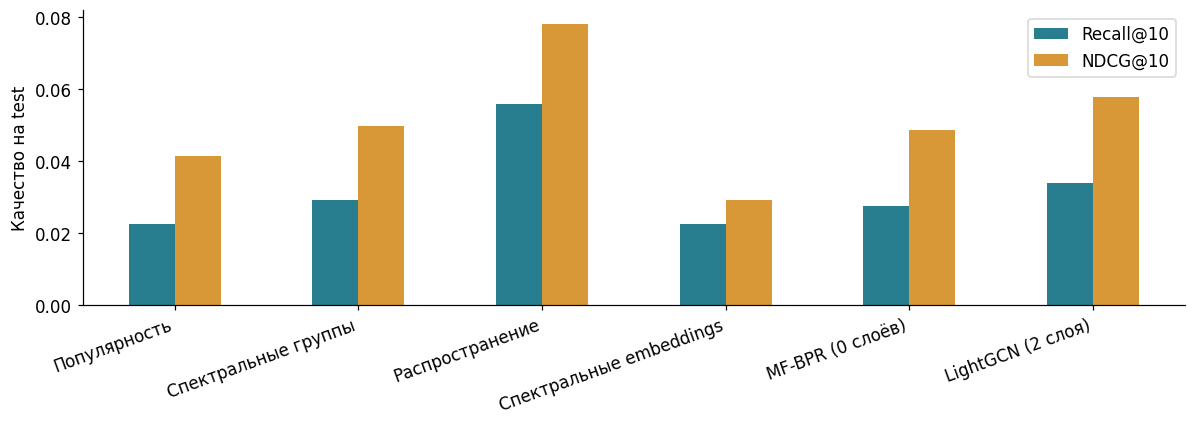

In [ ]:
validation = pd.DataFrame({name: evaluate(s, val_targets) for name, s in scores_by_model.items()}).T
chosen = validation['NDCG@10'].idxmax()
test_targets = make_targets(test_raw)
assert test_targets
results = pd.DataFrame({name: evaluate(s, test_targets) for name, s in scores_by_model.items()}).T
results.index.name = 'Модель'
print('Выбрана по validation:', chosen)
display(results.round(4))
results.to_csv(OUT / 'test_metrics.csv')
validation.to_csv(OUT / 'validation_metrics.csv')
ax = results[['Recall@10', 'NDCG@10']].plot.bar(figsize=(11, 4), color=['#287d8e', '#d99838'])
ax.set(ylabel='Качество на test', xlabel=''); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.savefig(FIG / '04_comparison.png'); plt.show()

### Как прочитать получившийся результат
В сохранённом запуске по validation выбрано **распространение по графу**.
На test его Recall@10 составил **5,59%** против **2,26%** у популярности;
NDCG@10 - **0,0781** против **0,0416**. Это примерно в 2,47 раза больше Recall,
но абсолютный прирост составляет 3,33 процентного пункта, а не 147 пунктов.

LightGCN получила Recall@10 **3,40%**, а модель без агрегации - **2,77%**.
При бюджете **100 шагов обучения по 8192 тройки** LightGCN превзошла факторизацию,
но уступила распространению по графу. Этот вывод относится к заданному бюджету и настройкам.
Обе обучаемые модели достигли лучшего validation NDCG@10 на последнем проверенном шаге,
а LightGCN продолжала улучшаться к концу запуска. Поэтому её сходимость и предел качества
не установлены; общего превосходства распространения над LightGCN эксперимент не доказывает.

Для дальнейшего сравнения бюджет увеличивают и момент остановки выбирают по validation.
Поскольку текущий test уже просмотрен, новую итоговую оценку проводят на другом заранее
отложенном периоде. Увеличивать бюджет, пока не улучшится текущий test, нельзя.

Спектральные группы улучшили популярность, а рекомендации по спектральным embeddings
не улучшили NDCG. Представление, удобное для выделения групп, не обязано быть оптимальным для ранжирования.
После изменения параметров ориентируйтесь на заново вычисленные таблицы, а не на числа этого комментария.


### Посмотрим на конкретного покупателя
Берём пользователя с медианным размером обучающей истории среди оцениваемых - не выбираем
самый удачный пример по попаданиям. Показываем историю, рекомендации выбранной по validation модели
и факт будущей покупки. Названия определены по train.

In [ ]:
ordered_users = sorted(test_targets, key=lambda u: (len(seen[u]), u))
example_u = ordered_users[len(ordered_users) // 2]
print('Покупатель:', users[example_u], '| товаров в истории:', len(seen[example_u]))
history_ids = sorted(seen[example_u], key=lambda i: -pop[i])[:12]
display(pd.DataFrame({'Товар из истории': [names[items[i]] for i in history_ids]}))
rec = rank_topk(scores_by_model[chosen], [example_u])[0]
example = pd.DataFrame({'Место': np.arange(1, K+1), 'Код': items[rec],
                        'Рекомендация': [names[items[i]] for i in rec],
                        'Куплен в test': [i in test_targets[example_u] for i in rec]})
display(example)
example.to_csv(OUT / 'recommendation_example.csv', index=False)
print('Будущие новые покупки в каталоге:')
display(pd.DataFrame({'Товар': [names[items[i]] for i in sorted(test_targets[example_u])]}))

Покупатель: 16085 | товаров в истории: 48


,Товар из истории
0,HEART OF WICKER SMALL
1,JAM MAKING SET WITH JARS
2,JAM MAKING SET PRINTED
3,HEART OF WICKER LARGE
4,HOMEMADE JAM SCENTED CANDLES
5,COLOUR GLASS T-LIGHT HOLDER HANGING
6,PAPER CHAIN KIT EMPIRE
7,RED HANGING HEART T-LIGHT HOLDER
8,LOVE BUILDING BLOCK WORD
9,VINTAGE SNAP CARDS


,Место,Код,Рекомендация,Куплен в test
0,1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,True
1,2,22620,4 TRADITIONAL SPINNING TOPS,True
2,3,85049H,URBAN BLACK RIBBONS,False
3,4,22077,6 RIBBONS RUSTIC CHARM,False
4,5,21890,S/6 WOODEN SKITTLES IN COTTON BAG,False
5,6,22561,WOODEN SCHOOL COLOURING SET,False
6,7,21915,RED HARMONICA IN BOX,True
7,8,21703,BAG 125g SWIRLY MARBLES,False
8,9,22491,PACK OF 12 COLOURED PENCILS,False
9,10,22457,NATURAL SLATE HEART CHALKBOARD,False


Будущие новые покупки в каталоге:


,Товар
0,PINK BLUE FELT CRAFT TRINKET BOX
1,PINK CREAM FELT CRAFT TRINKET BOX
2,BLUE HARMONICA IN BOX
3,RED HARMONICA IN BOX
4,SET 12 KIDS WHITE CHALK STICKS
5,SET 12 KIDS COLOUR CHALK STICKS
6,PAPER CHAIN KIT 50'S CHRISTMAS
7,PARTY CONE CHRISTMAS DECORATION
8,CHRISTMAS CRAFT WHITE FAIRY
9,CHRISTMAS CRAFT LITTLE FRIENDS


## 8. Что мы можем сказать бизнесу?
Сравнивайте таблицу, а не сложность названия алгоритма. Даже если LightGCN выигрывает,
один временной срез и один seed ещё не доказывают устойчивое преимущество.

- **Если выигрывает популярность:** сложное решение пока не оправдано этим экспериментом.
- **Если выигрывает распространение:** полезная структура есть уже в совместных покупках.
- **Если embeddings или LightGCN дают выигрыш:** следующий шаг - проверить другие временные окна,
  сезонность и качество для редких товаров, затем спроектировать онлайн-эксперимент.
- Покупки по рекомендациям, возвраты, маржа и пользовательский опыт проверяются в продукте.
  Здесь нет данных, чтобы оценить причинный прирост продаж.

**Ограничения:** оптовые заказы, сезонные подарки, удалённые возвраты, отсутствие остатков и показов;
ограниченный каталог; только известные пользователи; новые товары без истории не получают embeddings.
В этой реализации LightGCN использует ID и связи, но не текст или цену. Это transductive постановка.

Мы решили **link prediction / ranking** на графе «пользователь - товар».
Node classification и graph classification - другие задачи: например, категория товара или метка целого
графа сессии. В этой таблице нет надёжных меток таких задач, поэтому не подменяем их искусственным экспериментом.

Сравнение всей и недавней истории отвечает на новый вопрос из начала лекции: может ли состав
последних заказов изменить выдачу при том же графе и каталоге. Улучшение на validation не гарантировано.
Отдельный пример показывает изменение рекомендаций, а таблица всей когорты показывает качество.


In [ ]:
import platform, sklearn, scipy
run_info = {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
            'scipy': scipy.__version__, 'sklearn': sklearn.__version__, 'torch': torch.__version__,
            'seed': SEED, 'users': nu, 'items': ni, 'train_edges': R.nnz,
            'validation_users': len(val_targets), 'test_users': len(test_targets),
            'selected_by_validation': chosen, 'step_mf': step_mf, 'step_lightgcn': step_gcn,
            'training_steps': TRAIN_STEPS, 'batch_size': BATCH,
            'mf_best_at_budget_limit': step_mf == TRAIN_STEPS,
            'lightgcn_best_at_budget_limit': step_gcn == TRAIN_STEPS,
            'recent_days': RECENT_DAYS,
            'recency_evaluation_split': 'validation_only',
            'recency_validation_users_with_recent': len(recent_validation_targets),
            'recency_example_customer': str(users[recency_u]),
            'runtime_seconds': round(time.time() - START, 1)}
(OUT / 'run_info.json').write_text(json.dumps(run_info, ensure_ascii=False, indent=2))
print(f"Готово за {run_info['runtime_seconds']} с. Таблицы в Результаты/, рисунки в Рисунки/.")

Готово за 20.2 с. Таблицы в Результаты/, рисунки в Рисунки/.
